# Agentic AI Business Intelligence Assistant

## Project Overview

This project combines Power BI, Python, and Google's Gemini AI to build an intelligent business assistant capable of analyzing business data, generating executive reports, answering natural language business questions, and providing actionable recommendations.

### Objectives
- Analyze sales and profit performance
- Generate executive and monthly business reports
- Identify business trends and key performance indicators (KPIs)
- Answer business questions using Generative AI
- Provide AI-driven business recommendations

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns:
(9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [ ]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [ ]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [ ]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [ ]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [ ]:
furniture = df[df['Category'] == 'Furniture']

print("Average Discount:", furniture['Discount'].mean())

print("Total Sales:", furniture['Sales'].sum())

print("Total Profit:", furniture['Profit'].sum())

Average Discount: 0.1739226779820839
Total Sales: 741999.7953
Total Profit: 18451.272800000006


In [ ]:
furniture_sub = furniture.groupby('Sub-Category')['Profit'].sum().sort_values()

print(furniture_sub)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Furnishings    13059.1436
Chairs         26590.1663
Name: Profit, dtype: float64


In [ ]:
tables = furniture[furniture['Sub-Category'] == 'Tables']

print("Average Discount:", tables['Discount'].mean())
print("Total Sales:", tables['Sales'].sum())
print("Total Profit:", tables['Profit'].sum())

Average Discount: 0.26128526645768024
Total Sales: 206965.532
Total Profit: -17725.4811


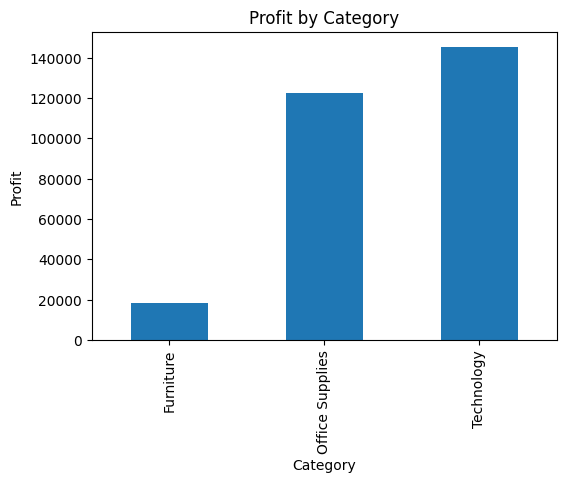

In [ ]:
import matplotlib.pyplot as plt

category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(6,4))
category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

In [ ]:
top_loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

print(top_loss_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


In [ ]:
loss_products = df.groupby('Product Name').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Discount':'mean'
})

loss_products = loss_products.sort_values('Profit').head(10)

print(loss_products)

                                                        Sales     Profit  \
Product Name                                                               
Cubify CubeX 3D Printer Double Head Print           11099.963 -8879.9704   
Lexmark MX611dhe Monochrome Laser Printer           16829.901 -4589.9730   
Cubify CubeX 3D Printer Triple Head Print            7999.980 -3839.9904   
Chromcraft Bull-Nose Wood Oval Conference Table...   9917.640 -2876.1156   
Bush Advantage Collection Racetrack Conference ...   9544.725 -1934.3976   
GBC DocuBind P400 Electric Binding System           17965.068 -1878.1662   
Cisco TelePresence System EX90 Videoconferencin...  22638.480 -1811.0784   
Martin Yale Chadless Opener Electric Letter Opener  16656.200 -1299.1836   
Balt Solid Wood Round Tables                         6518.754 -1201.0581   
BoxOffice By Design Rectangular and Half-Moon M...   1706.250 -1148.4375   

                                                    Discount  
Product Name            

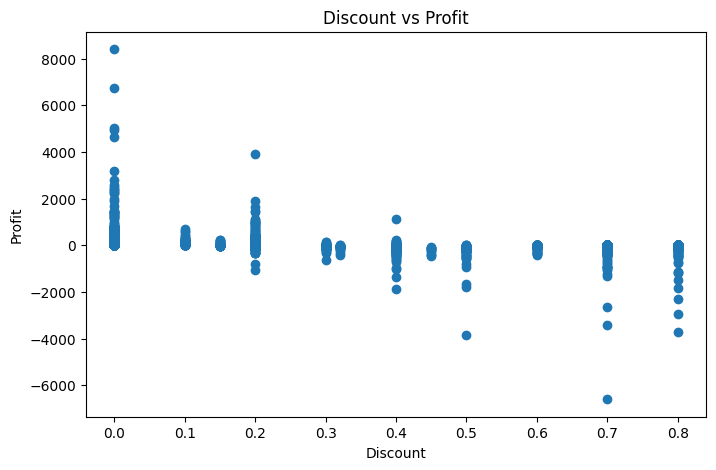

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df['Discount'], df['Profit'])

plt.xlabel("Discount")
plt.ylabel("Profit")

plt.title("Discount vs Profit")

plt.show()

In [ ]:
def business_recommendation(category):

    if category == "Furniture":
        return """
        Furniture category shows low profitability.
        Tables and Bookcases are generating losses.
        Recommended Action:
        - Reduce excessive discounts.
        - Review pricing strategy.
        - Promote high-margin furniture products.
        """

    elif category == "Technology":
        return """
        Technology category is highly profitable.
        Recommended Action:
        - Increase marketing investment.
        - Focus on premium products.
        - Maintain current discount strategy.
        """

    elif category == "Office Supplies":
        return """
        Office Supplies shows stable profits.
        Recommended Action:
        - Expand inventory.
        - Bundle frequently purchased products.
        - Improve cross-selling.
        """

print(business_recommendation("Furniture"))


        Furniture category shows low profitability.
        Tables and Bookcases are generating losses.
        Recommended Action:
        - Reduce excessive discounts.
        - Review pricing strategy.
        - Promote high-margin furniture products.
        


In [ ]:
query = input("Ask a business question: ")

if "highest profit category" in query.lower():
    print(df.groupby('Category')['Profit'].sum().idxmax())

elif "highest profit region" in query.lower():
    print(df.groupby('Region')['Profit'].sum().idxmax())

elif "furniture" in query.lower():
    print(business_recommendation("Furniture"))

else:
    print("Question not supported yet.")

Ask a business question: highest profit region
West


In [ ]:
def agentic_bi(query):

    query = query.lower()

    if "highest profit category" in query:

        category = df.groupby('Category')['Profit'].sum().idxmax()
        profit = df.groupby('Category')['Profit'].sum().max()

        return f"""
Highest Profit Category: {category}

Profit: ${profit:.2f}

Recommendation:
Increase investment and marketing in this category.
"""

    elif "highest profit region" in query:

        region = df.groupby('Region')['Profit'].sum().idxmax()
        profit = df.groupby('Region')['Profit'].sum().max()

        return f"""
Highest Profit Region: {region}

Profit: ${profit:.2f}

Recommendation:
Focus future expansion strategies in this region.
"""

    elif "furniture" in query:

        return """
Furniture category shows low profitability.

Root Cause:
- Tables are generating major losses.
- High discounts are reducing profit margins.

Recommendation:
- Reduce discount levels.
- Re-evaluate pricing strategy.
- Promote profitable furniture products.
"""

    else:
        return "Question not supported."

query = input("Ask your question: ")

print(agentic_bi(query))

Ask your question: highest profit region

Highest Profit Region: West

Profit: $108418.45

Recommendation:
Focus future expansion strategies in this region.



In [ ]:
def generate_business_insights(df):

    insights = []

    # Highest profit category
    top_category = df.groupby('Category')['Profit'].sum().idxmax()
    top_category_profit = df.groupby('Category')['Profit'].sum().max()

    insights.append(
        f"Technology category generated the highest profit (${top_category_profit:.2f})."
    )

    # Highest profit region
    top_region = df.groupby('Region')['Profit'].sum().idxmax()
    top_region_profit = df.groupby('Region')['Profit'].sum().max()

    insights.append(
        f"{top_region} region generated the highest profit (${top_region_profit:.2f})."
    )

    # Lowest profit category
    low_category = df.groupby('Category')['Profit'].sum().idxmin()
    low_category_profit = df.groupby('Category')['Profit'].sum().min()

    insights.append(
        f"{low_category} category generated the lowest profit (${low_category_profit:.2f})."
    )

    # Loss making subcategory
    loss_sub = df.groupby('Sub-Category')['Profit'].sum().idxmin()
    loss_sub_profit = df.groupby('Sub-Category')['Profit'].sum().min()

    insights.append(
        f"{loss_sub} sub-category generated the highest loss (${loss_sub_profit:.2f})."
    )

    # Discount impact
    avg_discount = df['Discount'].mean()

    insights.append(
        f"Average discount across products is {avg_discount:.2f}. Higher discounts are associated with lower profits."
    )

    return insights


insights = generate_business_insights(df)

for i, insight in enumerate(insights, start=1):
    print(f"Insight {i}: {insight}")

Insight 1: Technology category generated the highest profit ($145454.95).
Insight 2: West region generated the highest profit ($108418.45).
Insight 3: Furniture category generated the lowest profit ($18451.27).
Insight 4: Tables sub-category generated the highest loss ($-17725.48).
Insight 5: Average discount across products is 0.16. Higher discounts are associated with lower profits.


In [ ]:
def executive_summary():

    summary = f"""
EXECUTIVE BUSINESS SUMMARY

Total Sales: ${df['Sales'].sum():,.2f}

Total Profit: ${df['Profit'].sum():,.2f}

Key Findings:

1. Technology is the most profitable category with profit of
${df.groupby('Category')['Profit'].sum().max():,.2f}

2. West region generated the highest profit of
${df.groupby('Region')['Profit'].sum().max():,.2f}

3. Furniture is the least profitable category and requires immediate attention.

4. Tables sub-category generated the highest loss
(${df.groupby('Sub-Category')['Profit'].sum().min():,.2f})

5. Higher discounts are strongly associated with reduced profitability.

Strategic Recommendations:

• Reduce excessive discounts on loss-making products.

• Reassess pricing strategy for Furniture category.

• Expand operations in West region.

• Increase focus on Technology products.

• Monitor high-discount products through AI-based alerts.

"""

    return summary

print(executive_summary())


EXECUTIVE BUSINESS SUMMARY

Total Sales: $2,297,200.86

Total Profit: $286,397.02

Key Findings:

1. Technology is the most profitable category with profit of
$145,454.95

2. West region generated the highest profit of
$108,418.45

3. Furniture is the least profitable category and requires immediate attention.

4. Tables sub-category generated the highest loss
($-17,725.48)

5. Higher discounts are strongly associated with reduced profitability.

Strategic Recommendations:

• Reduce excessive discounts on loss-making products.

• Reassess pricing strategy for Furniture category.

• Expand operations in West region.

• Increase focus on Technology products.

• Monitor high-discount products through AI-based alerts.




In [ ]:
furniture_profit = df[df['Category']=="Furniture"]["Profit"].sum()

if furniture_profit < 20000:
    print("🚨ALERT: Furniture category is underperforming")
    print(f"Current Profit: ${furniture_profit:.2f}")

🚨 ALERT: Furniture category is underperforming
Current Profit: $18451.27


In [ ]:
tables_profit = df[df['Sub-Category']=="Tables"]["Profit"].sum()

if tables_profit < 0:
    print("🚨 ALERT: Tables sub-category is generating losses")
    print(f"Current Loss: ${tables_profit:.2f}")

🚨 ALERT: Tables sub-category is generating losses
Current Loss: $-17725.48


In [ ]:
def generate_alerts(df):

    alerts = []

    furniture_profit = df[df['Category']=="Furniture"]['Profit'].sum()

    if furniture_profit < 20000:
        alerts.append(
            f"Furniture category profit is low (${furniture_profit:.2f})"
        )

    tables_profit = df[df['Sub-Category']=="Tables"]['Profit'].sum()

    if tables_profit < 0:
        alerts.append(
            f"Tables sub-category loss detected (${tables_profit:.2f})"
        )

    avg_discount = df['Discount'].mean()

    if avg_discount > 0.15:
        alerts.append(
            f"High average discount detected ({avg_discount:.2f})"
        )

    return alerts


for alert in generate_alerts(df):
    print("🚨", alert)

🚨 Furniture category profit is low ($18451.27)
🚨 Tables sub-category loss detected ($-17725.48)
🚨 High average discount detected (0.16)


In [ ]:
def smart_alerts(df):

    furniture_profit = df[df['Category']=="Furniture"]['Profit'].sum()

    if furniture_profit < 20000:

        print("🚨 ALERT: Furniture Category Underperforming")

        print(f"Profit: ${furniture_profit:.2f}")

        print("\nPossible Causes:")

        print("- Tables generating losses")

        print("- High discounts reducing margins")

        print("\nRecommended Actions:")

        print("- Reduce discount levels")

        print("- Review pricing strategy")

        print("- Focus on profitable furniture items")


smart_alerts(df)

🚨 ALERT: Furniture Category Underperforming
Profit: $18451.27

Possible Causes:
- Tables generating losses
- High discounts reducing margins

Recommended Actions:
- Reduce discount levels
- Review pricing strategy
- Focus on profitable furniture items


In [ ]:
def business_health_score(df):

    total_profit = df['Profit'].sum()

    if total_profit > 250000:
        score = 90
    elif total_profit > 150000:
        score = 75
    else:
        score = 60

    print("📊 BUSINESS HEALTH SCORE")
    print(f"\nOverall Score: {score}/100")

    category_profit = df.groupby('Category')['Profit'].sum()

    for category, profit in category_profit.items():

        if profit > 100000:
            status = "🟢 Excellent"

        elif profit > 50000:
            status = "🟡 Good"

        else:
            status = "🔴 Needs Attention"

        print(f"\n{category}: {status}")
        print(f"Profit: ${profit:.2f}")

business_health_score(df)

📊 BUSINESS HEALTH SCORE

Overall Score: 90/100

Furniture: 🔴 Needs Attention
Profit: $18451.27

Office Supplies: 🟢 Excellent
Profit: $122490.80

Technology: 🟢 Excellent
Profit: $145454.95


In [ ]:
project_results = {
    "Total Sales": df['Sales'].sum(),
    "Total Profit": df['Profit'].sum(),
    "Highest Profit Category": df.groupby('Category')['Profit'].sum().idxmax(),
    "Highest Profit Region": df.groupby('Region')['Profit'].sum().idxmax(),
    "Lowest Profit Category": df.groupby('Category')['Profit'].sum().idxmin(),
    "Highest Loss SubCategory": df.groupby('Sub-Category')['Profit'].sum().idxmin()
}

project_results

{'Total Sales': np.float64(2297200.8603000003),
 'Total Profit': np.float64(286397.0217),
 'Highest Profit Category': 'Technology',
 'Highest Profit Region': 'West',
 'Lowest Profit Category': 'Furniture',
 'Highest Loss SubCategory': 'Tables'}

In [ ]:
def generate_business_report(df):

    total_sales = df['Sales'].sum()
    total_profit = df['Profit'].sum()

    best_category = df.groupby('Category')['Profit'].sum().idxmax()
    best_category_profit = df.groupby('Category')['Profit'].sum().max()

    best_region = df.groupby('Region')['Profit'].sum().idxmax()
    best_region_profit = df.groupby('Region')['Profit'].sum().max()

    worst_category = df.groupby('Category')['Profit'].sum().idxmin()

    worst_subcategory = df.groupby('Sub-Category')['Profit'].sum().idxmin()
    worst_subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().min()

    report = f"""

EXECUTIVE BUSINESS SUMMARY

Total Sales: ${total_sales:,.2f}

Total Profit: ${total_profit:,.2f}

Key Findings:

1. {best_category} is the most profitable category with profit of
${best_category_profit:,.2f}

2. {best_region} region generated the highest profit of
${best_region_profit:,.2f}

3. {worst_category} is the least profitable category.

4. {worst_subcategory} generated the highest loss
(${worst_subcategory_profit:,.2f})

5. Higher discounts are reducing profitability.

Strategic Recommendations:

• Reduce excessive discounts.

• Reassess pricing strategy.

• Expand in profitable regions.

• Increase focus on high-profit products.

• Monitor loss-making categories through AI alerts.

"""

    return report

In [ ]:
print(generate_business_report(df))



EXECUTIVE BUSINESS SUMMARY

Total Sales: $2,297,200.86

Total Profit: $286,397.02

Key Findings:

1. Technology is the most profitable category with profit of
$145,454.95

2. West region generated the highest profit of
$108,418.45

3. Furniture is the least profitable category.

4. Tables generated the highest loss
($-17,725.48)

5. Higher discounts are reducing profitability.

Strategic Recommendations:

• Reduce excessive discounts.

• Reassess pricing strategy.

• Expand in profitable regions.

• Increase focus on high-profit products.

• Monitor loss-making categories through AI alerts.




In [ ]:
query = input("Generate Report Type: ")

if "monthly" in query.lower():
    print(generate_business_report(df))

elif "executive" in query.lower():
    print(generate_business_report(df))

else:
    print("Report type not supported")

Generate Report Type: Monthly Business Report


EXECUTIVE BUSINESS SUMMARY

Total Sales: $2,297,200.86

Total Profit: $286,397.02

Key Findings:

1. Technology is the most profitable category with profit of
$145,454.95

2. West region generated the highest profit of
$108,418.45

3. Furniture is the least profitable category.

4. Tables generated the highest loss
($-17,725.48)

5. Higher discounts are reducing profitability.

Strategic Recommendations:

• Reduce excessive discounts.

• Reassess pricing strategy.

• Expand in profitable regions.

• Increase focus on high-profit products.

• Monitor loss-making categories through AI alerts.




In [ ]:
query = input("Ask business question: ")

prompt = f"""
Business Summary:

Total Sales: {df['Sales'].sum()}
Total Profit: {df['Profit'].sum()}

Highest Profit Category:
{df.groupby('Category')['Profit'].sum().idxmax()}

Highest Profit Region:
{df.groupby('Region')['Profit'].sum().idxmax()}

Question:
{query}
"""

response = model.generate_content(prompt)

print(response.text)

Ask business question: What strategy can improve profit next quarter?
Based on the current business metrics—specifically a healthy **12.47% profit margin** ($286,397 profit on $2,297,200 sales), with **Technology** and the **West** region driving the highest profitability—here is a targeted strategy to improve profits next quarter:

### 1. Double Down on the "West" Region (Replicate & Expand)
Since the West is your most profitable region, you should capitalize on this momentum immediately.
*   **Allocate Marketing Spend:** Shift a larger portion of next quarter’s marketing budget to the West region to acquire more high-value customers.
*   **Analyze the Blueprint:** Analyze *why* the West is winning. Is it a specific sales team, a specific product mix, or lower logistics costs? Document these best practices and begin training teams in lagging regions (e.g., East, Central, or South) to replicate the West's sales model.

### 2. Maximize the "Technology" Category (Upsell & Cross-Sell)
Tec

In [ ]:
!pip install -q google-generativeai

In [4]:
import google.generativeai as genai

genai.configure(api_key="YOUR_API_KEY")

In [ ]:
model = genai.GenerativeModel("gemini-2.5-flash")

response = model.generate_content("Say hello in one sentence")

print(response.text)

Hello!


In [ ]:
question = """
Business Summary:

Total Sales: 2297200.86
Total Profit: 286397.02

Category Profits:
Technology: 145454.95
Furniture: 18451.27
Office Supplies: 122490.80

Based on this data, give 3 business recommendations.
"""

response = model.generate_content(question)

print(response.text)

Based on the provided data, here are 3 business recommendations:

1.  **Capitalize on Technology's Success:** Technology is the highest profit-generating category by a significant margin. Focus on this strength by investing further in this area. This could involve expanding the product range, increasing marketing efforts specifically for technology products, exploring related services, or optimizing the supply chain to further enhance its already strong profitability.

2.  **Evaluate and Improve Furniture Performance:** The Furniture category generates significantly less profit than the other two. Conduct a thorough analysis to understand the reasons for its underperformance (e.g., low sales volume, high costs, low margins, high return rates, competitive pricing). Based on this analysis, either strategize to improve its profitability (e.g., optimize pricing, source cheaper, improve marketing, streamline operations) or consider re-evaluating its place in the product portfolio if it cons

In [ ]:
def ask_bi_agent(question):

    context = f"""
    Business Summary:

    Total Sales: {total_sales}
    Total Profit: {total_profit}

    Category Profit:
    {category_profit.to_string()}
    """

    prompt = context + "\n\nQuestion: " + question

    response = model.generate_content(prompt)

    return response.text

In [ ]:
print(ask_bi_agent("Which category needs immediate attention?"))

Based on the provided category profit data:

*   **Furniture:** $18,451.27
*   **Office Supplies:** $122,490.80
*   **Technology:** $145,454.95

**Furniture** needs immediate attention. Its profit of **$18,451.27** is significantly lower than the other categories, indicating it might be underperforming, facing higher costs, or experiencing lower sales.


# Conclusion

This project demonstrates how Generative AI can be integrated with traditional Business Intelligence workflows to provide interactive business insights and strategic decision support.

### Future Enhancements
- Streamlit Dashboard
- Power BI Integration
- PDF Report Generation
- Voice-based Business Assistant
- Multi-dataset Support
- Real-time Business Analytics

Thank you for reviewing this project.